# Customer Segment Analysis

## Day 44

### 목적

Olist 분석기간의 Item Sales와 Buyer Count를
신규 고객과 기존 고객으로 분해하고,
신규 고객의 90일 재구매율을 확인한다.

### 고객 정의

New Customer:
관측 가능한 최초 delivered 주문 월이
현재 주문 월과 같은 customer_unique_id

Existing Customer:
최초 delivered 주문 월 이후에
다시 구매한 customer_unique_id

### 주의

Olist 데이터 시작 이전의 구매 이력은 알 수 없으므로
First Purchase는 실제 생애 최초 구매가 아니라
First Observed Purchase를 의미한다.

In [1]:
from pathlib import Path

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
project_root = Path.cwd().parent

database_path = (
    project_root
    / "data"
    / "processed"
    / "olist.db"
)

report_dir = (
    project_root
    / "reports"
)

figure_dir = (
    report_dir
    / "figures"
)

connection = sqlite3.connect(
    database_path
)

In [4]:
monthly_customer_segment_df = pd.read_sql_query(
    """
    WITH customer_first_purchase AS (
        SELECT
            c.customer_unique_id,

            min(
                o.order_purchase_timestamp
            ) AS first_purchase_timestamp,

            substr(
                min(
                    o.order_purchase_timestamp
                ),
                1,
                7
            ) AS first_purchase_month

        FROM orders AS o

        JOIN customers AS c
            ON o.customer_id = c.customer_id
        
        WHERE
            o.order_status = 'delivered'

        GROUP BY
            c.customer_unique_id
    ),

    segmented_orders AS (
        SELECT
            ao.order_month,
            ao.order_id,
            ao.customer_unique_id,
            ao.item_sales,

            CASE
                WHEN ao.order_month = fp.first_purchase_month
                    THEN 'new'
                ELSE 'existing'
            END AS customer_segment

        FROM analysis_orders AS ao

        JOIN customer_first_purchase AS fp
            ON ao.customer_unique_id = fp.customer_unique_id
    )

    SELECT
        order_month,

        sum(
            CASE
                WHEN customer_segment = 'new'
                    THEN item_sales
                ELSE 0
            END
        ) AS new_item_sales,

        sum(
            CASE
                WHEN customer_segment = 'existing'
                    THEN item_sales
                ELSE 0
            END
        ) AS existing_item_sales,

        sum(
            item_sales
        ) AS total_item_sales,

        count(
            DISTINCT CASE
                WHEN customer_segment = 'new'
                THEN customer_unique_id                
            END
        ) AS new_buyer_count,

        count(
            DISTINCT CASE
                WHEN customer_segment = 'existing'
                THEN customer_unique_id                
            END
        ) AS existing_buyer_count,

        count(
            DISTINCT customer_unique_id                
        ) AS total_buyer_count
    
    FROM segmented_orders

    GROUP BY
        order_month

    ORDER BY
        order_month        
    """,
    connection
)

print(
    monthly_customer_segment_df
)

   order_month  new_item_sales  existing_item_sales  total_item_sales  \
0      2017-09       597783.07              9616.60         607399.67   
1      2017-10       636772.38             11475.27         648247.65   
2      2017-11       972614.06             15151.31         987765.37   
3      2017-12       709843.58             16189.61         726033.19   
4      2018-01       906733.35             17911.65         924645.00   
5      2018-02       813053.18             13383.95         826437.13   
6      2018-03       937192.39             16163.86         953356.25   
7      2018-04       952665.48             20868.61         973534.09   
8      2018-05       953140.05             24404.64         977544.69   
9      2018-06       830699.75             25378.11         856077.86   
10     2018-07       847944.56             20008.90         867953.46   
11     2018-08       820059.08             18517.56         838576.64   

    new_buyer_count  existing_buyer_count  total_b

In [17]:
# 비중 계산
monthly_customer_segment_df[
    "new_item_sales_share"
] = (
    monthly_customer_segment_df["new_item_sales"]
    / monthly_customer_segment_df["total_item_sales"]
)

monthly_customer_segment_df[
    "existing_item_sales_share"
] = (
    monthly_customer_segment_df["existing_item_sales"]
    / monthly_customer_segment_df["total_item_sales"]
)

monthly_customer_segment_df[
    "new_buyer_share"
] = (
    monthly_customer_segment_df["new_buyer_count"]
    / monthly_customer_segment_df["total_buyer_count"]
)

monthly_customer_segment_df[
    "existing_buyer_share"
] = (
    monthly_customer_segment_df["existing_buyer_count"]
    / monthly_customer_segment_df["total_buyer_count"]
)

print(
    monthly_customer_segment_df[
        [
            "order_month",
            "new_item_sales_share",
            "existing_item_sales_share",
            "new_buyer_share",
            "existing_buyer_share"
        ]
    ]
)

   order_month  new_item_sales_share  existing_item_sales_share  \
0      2017-09              0.984168                   0.015832   
1      2017-10              0.982298                   0.017702   
2      2017-11              0.984661                   0.015339   
3      2017-12              0.977701                   0.022299   
4      2018-01              0.980629                   0.019371   
5      2018-02              0.983805                   0.016195   
6      2018-03              0.983045                   0.016955   
7      2018-04              0.978564                   0.021436   
8      2018-05              0.975035                   0.024965   
9      2018-06              0.970355                   0.029645   
10     2018-07              0.976947                   0.023053   
11     2018-08              0.977918                   0.022082   

    new_buyer_share  existing_buyer_share  
0          0.980651              0.019349  
1          0.979851              0.02014

In [6]:
# 검산
monthly_customer_segment_df[
    "item_sales_difference"
] = (
    monthly_customer_segment_df["total_item_sales"]
    - monthly_customer_segment_df["new_item_sales"]
    - monthly_customer_segment_df["existing_item_sales"]
)

monthly_customer_segment_df[
    "buyer_count_difference"
] = (
    monthly_customer_segment_df["total_buyer_count"]
    - monthly_customer_segment_df["new_buyer_count"]
    - monthly_customer_segment_df["existing_buyer_count"]
)

print(
    monthly_customer_segment_df[
        [
            "order_month",
            "item_sales_difference",
            "buyer_count_difference"
        ]
    ]
)

   order_month  item_sales_difference  buyer_count_difference
0      2017-09           9.276846e-11                       0
1      2017-10           1.818989e-11                       0
2      2017-11          -6.002665e-11                       0
3      2017-12           1.018634e-10                       0
4      2018-01           2.182787e-11                       0
5      2018-02          -4.729372e-11                       0
6      2018-03          -1.455192e-11                       0
7      2018-04          -1.455192e-11                       0
8      2018-05           1.455192e-11                       0
9      2018-06          -1.455192e-11                       0
10     2018-07          -9.458745e-11                       0
11     2018-08           5.456968e-11                       0


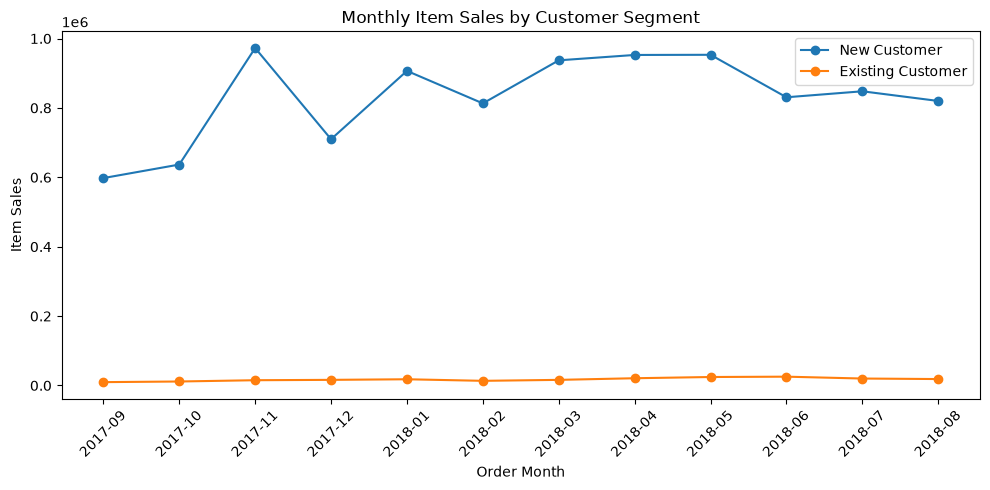

In [7]:
# 신규/기존 Item Sales 그래프
plt.figure(
    figsize=(10, 5)
)

plt.plot(
    monthly_customer_segment_df["order_month"],
    monthly_customer_segment_df["new_item_sales"],
    marker="o",
    label="New Customer"
)

plt.plot(
    monthly_customer_segment_df["order_month"],
    monthly_customer_segment_df["existing_item_sales"],
    marker="o",
    label="Existing Customer"
)

plt.title(
    "Monthly Item Sales by Customer Segment"
)

plt.xlabel(
    "Order Month"
)

plt.ylabel(
    "Item Sales"
)

plt.xticks(
    rotation=45
)

plt.legend()

plt.tight_layout()

plt.savefig(
    figure_dir
    / "monthly_new_existing_item_sales.png",
    dpi=150
)

plt.show()

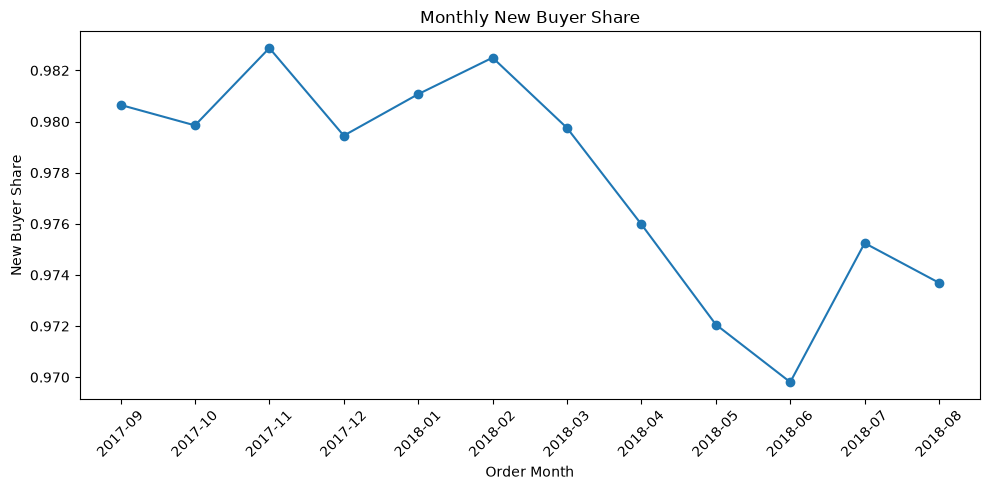

In [8]:
# New Buyer Share 그래프
plt.figure(
    figsize=(10, 5)
)

plt.plot(
    monthly_customer_segment_df["order_month"],
    monthly_customer_segment_df["new_buyer_share"],
    marker="o"
)

plt.title(
    "Monthly New Buyer Share"
)

plt.xlabel(
    "Order Month"
)

plt.ylabel(
    "New Buyer Share"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.savefig(
    figure_dir
    / "monthly_new_buyer_share.png",
    dpi=150
)

plt.show()

In [9]:
# 90일 재구매율
repeat_90_df = pd.read_sql_query(
    """
    WITH delivered_orders AS (

        SELECT
            c.customer_unique_id,
            o.order_id,
            o.order_purchase_timestamp
            
        FROM orders AS o
        
        JOIN customers AS c
            ON o.customer_id = c.customer_id
        
        WHERE
            o.order_status = 'delivered'
    ),

    first_purchase AS (
        
        SELECT
            customer_unique_id,
            
            min(
                order_purchase_timestamp
            ) AS first_purchase_timestamp
            
        FROM delivered_orders
        
        GROUP BY
            customer_unique_id
    ),

    eligible_new_customers AS (
        
        SELECT
            customer_unique_id,
            first_purchase_timestamp
        
        FROM first_purchase
        
        WHERE
            first_purchase_timestamp >= '2017-09-01'
            
            AND date(
                first_purchase_timestamp,
                '+90 days'
            ) < '2018-09-01'
    ),

    repeat_flag AS (
        
        SELECT
            e.customer_unique_id,
            
            CASE
                WHEN count(
                    DISTINCT CASE
                        WHEN date(
                            d.order_purchase_timestamp
                        ) > date(
                            e.first_purchase_timestamp
                        )
                        
                        AND date(
                            d.order_purchase_timestamp
                        ) <= date(
                            e.first_purchase_timestamp,
                            '+90 days'
                        )
                        
                        THEN d.order_id
                    END
                ) > 0
                THEN 1
                
                ELSE 0
            END AS repeat_90
        
        FROM eligible_new_customers AS e
        
        LEFT JOIN delivered_orders AS d
            ON e.customer_unique_id = d.customer_unique_id
        
        GROUP BY
            e.customer_unique_id
    )

    SELECT
        count(*) AS eligible_new_customer_count,
        
        sum(
            repeat_90
        ) AS repeat_90_customer_count,
        
        round(
            avg(
                repeat_90 * 1.0
            ),
            4
        ) AS repeat_90_rate

    FROM repeat_flag
    """,
    connection
)

print(
    repeat_90_df
)

   eligible_new_customer_count  repeat_90_customer_count  repeat_90_rate
0                        54038                       693          0.0128


In [10]:
# csv 저장
monthly_customer_segment_df.to_csv(
    report_dir
    / "monthly_customer_segment.csv",
    index=False
)

repeat_90_df.to_csv(
    report_dir
    / "repeat_90_summary.csv",
    index=False
)

In [16]:
october_df = (
    monthly_customer_segment_df[
        monthly_customer_segment_df[
            "order_month"
        ] == "2017-10"
    ]
)

november_df = (
    monthly_customer_segment_df[
        monthly_customer_segment_df[
            "order_month"
        ] == "2017-11"
    ]
)

december_df = (
    monthly_customer_segment_df[
        monthly_customer_segment_df[
            "order_month"
        ] == "2017-12"
    ]
)

november_new_item_sales_change = (
    november_df["new_item_sales"].iloc[0]
    - october_df["new_item_sales"].iloc[0]
)

november_existing_item_sales_change = (
    november_df["existing_item_sales"].iloc[0]
    - october_df["existing_item_sales"].iloc[0]
)

november_new_buyer_change = (
    november_df["new_buyer_count"].iloc[0]
    - october_df["new_buyer_count"].iloc[0]
)

november_existing_buyer_change = (
    november_df["existing_buyer_count"].iloc[0]
    - october_df["existing_buyer_count"].iloc[0]
)

december_new_item_sales_change = (
    december_df["new_item_sales"].iloc[0]
    - november_df["new_item_sales"].iloc[0]
)

december_existing_item_sales_change = (
    december_df["existing_item_sales"].iloc[0]
    - november_df["existing_item_sales"].iloc[0]
)

december_new_buyer_change = (
    december_df["new_buyer_count"].iloc[0]
    - november_df["new_buyer_count"].iloc[0]
)

december_existing_buyer_change = (
    december_df["existing_buyer_count"].iloc[0]
    - november_df["existing_buyer_count"].iloc[0]
)

print(
    "New Item Sales Change:",
    november_new_item_sales_change
)

print(
    "Existing Item Sales Change:",
    november_existing_item_sales_change
)

print(
    "New Buyer Change:",
    november_new_buyer_change
)

print(
    "Existing Buyer Change:",
    november_existing_buyer_change
)

print(
    "New Item Sales Change:",
    december_new_item_sales_change
)

print(
    "Existing Item Sales Change:",
    december_existing_item_sales_change
)

print(
    "New Buyer Change:",
    december_new_buyer_change
)

print(
    "Existing Buyer Change:",
    december_existing_buyer_change
)

New Item Sales Change: 335841.68000000005
Existing Item Sales Change: 3676.039999999999
New Buyer Change: 2732
Existing Buyer Change: 34
New Item Sales Change: -262770.4800000001
Existing Item Sales Change: 1038.300000000001
New Buyer Change: -1722
Existing Buyer Change: -11


## Day 44 분석 결과

### 고객 정의

- Customer Key: customer_unique_id
- New Customer:
  관측 가능한 최초 delivered 주문 월이 현재 주문 월과 같은 고객
- Existing Customer:
  최초 관측 구매월 이후 다시 구매한 고객

### 신규/기존 고객

- 신규 Buyer 비중이 가장 높은 월: 2017년 11월
- 기존 Buyer 비중이 가장 높은 월: 2018년 6월
- 신규 Item Sales 비중이 가장 높은 월: 2017년 11월
- 기존 Item Sales 비중이 가장 높은 월: 2018년 6월

### 2017년 11월 증가

- New Customer Item Sales 변화: 335841.68
- Existing Customer Item Sales 변화: 3676.04
- New Buyer 변화: 2732
- Existing Buyer 변화: 34

해석:

- 2017년 11월 Item Sales 증가는 신규 고객 Item Sales 증가폭이 기존 고객보다 크게 나타났으며, Buyer Count에서도 신규 고객 증가가 더 크게 나타났다.
  따라서 11월의 전체 Item Sales 증가는 기존 고객의 구매 확대보다는 신규 구매고객 수 증가와 더 강하게 함께 나타난 것으로 해석할 수 있다.

### 2017년 12월 감소

- New Customer Item Sales 변화: -262770.48
- Existing Customer Item Sales 변화: 1038.30
- New Buyer 변화: -1722
- Existing Buyer 변화: -11

해석:

- 2017년 12월 Item Sales 감소는 신규 고객 Item Sales 감소폭이 기존 고객보다 크게 나타났으며, Buyer Count에서도 신규 고객 감소가 더 크게 나타났다.
  따라서 12월의 전체 Item Sales 감소는 기존 고객의 구매 이탈보다는 신규 구매고객 수 규모 축소와 더 강하게 함께 나타난 것으로 해석할 수 있다.

### 90일 재구매

- Eligible New Customers: 54038
- 90-day Repeat Customers: 693
- 90-day Repeat Rate: 0.0128

### 해석 한계

First Purchase는 실제 생애 최초 구매가 아니라
Olist 데이터에서 관측 가능한 최초 delivered 주문이다.

90일 재구매율은 관찰기간을 온전히 확보할 수 있는
신규 고객만 분모에 포함했다.

관찰된 재구매율 차이만으로
고객 충성도나 CRM 활동의 인과 효과를 판단할 수 없다.